# Neural Network (PyTorch)

In [1]:
import time
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Deterministic CPU execution: reproducibility takes priority over GPU speed
# for this small dataset (206 samples).
DEVICE = torch.device('cpu')
torch.use_deterministic_algorithms(True)

## Data Loading and Exploration

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/hepg2.csv')
# Exclude the 10 measurements at 2% DMSO (original INDEX 1-10): they were not
# collected in our laboratory, and 2% DMSO is not used in our experimental protocols.
df = df[df['% DMSO'] != 2.0].reset_index(drop=True)
print(f'Dataset: {df.shape[0]} samples, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}\n')
df.describe().round(2)

Dataset: 206 samples, 6 columns
Columns: ['INDEX', 'ESPÉCIE/LINHAGEM', '% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']



,INDEX,% DMSO,TREHALOSE,% SFB,VIABILIDADE
count,206.00,206.00,206.00,206.00,206.00
mean,113.50,21.65,17.77,57.09,41.86
std,59.61,28.30,27.20,30.03,35.97
min,11.00,0.00,0.00,0.00,0.00
25%,62.25,5.00,0.00,30.00,0.00
50%,113.50,5.00,0.00,67.50,48.94
75%,164.75,30.00,30.00,80.00,72.60
max,216.00,100.00,100.00,100.00,97.00


In [3]:
# Check for linear dependency between variables
# SFB = 100 - DMSO - TREHALOSE (in most cases)
# Therefore, SFB is linearly dependent on DMSO and TREHALOSE.
# Including it as a feature would introduce multicollinearity without adding new information.
df['SUM'] = df['% DMSO'] + df['TREHALOSE'] + df['% SFB']
print('Sum of DMSO + TREHALOSE + SFB:')
print(df['SUM'].value_counts())
df.drop('SUM', axis=1, inplace=True)

Sum of DMSO + TREHALOSE + SFB:
SUM
100.0    198
10.0       8
Name: count, dtype: int64


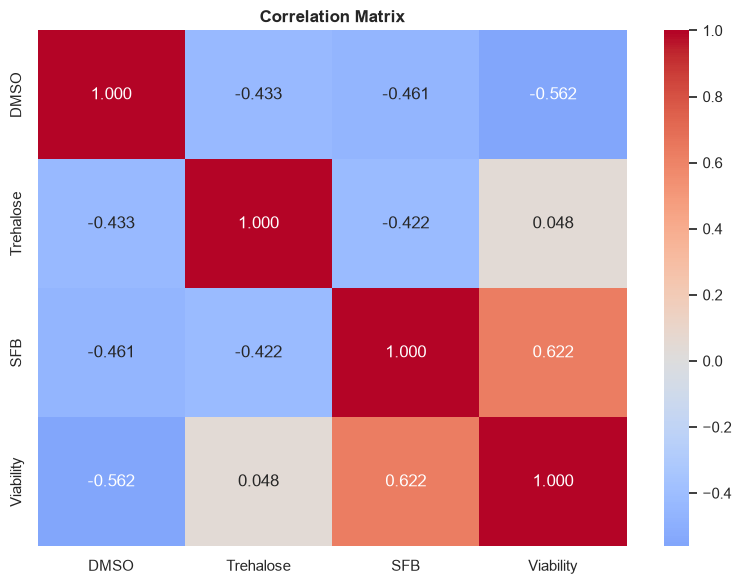

In [4]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']].corr()
corr = corr.rename(
    index={'% DMSO': 'DMSO', 'TREHALOSE': 'Trehalose', '% SFB': 'SFB', 'VIABILIDADE': 'Viability'},
    columns={'% DMSO': 'DMSO', 'TREHALOSE': 'Trehalose', '% SFB': 'SFB', 'VIABILIDADE': 'Viability'},
)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f',
    ax=ax
)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../static/images/eda_correlation_matrix.png', dpi=300)
plt.show()

Building Figure 1 (2 panels: A=DMSO, B=Trehalose)...
  Panel A (DMSO concentration): 13 discrete levels, n per level = [46, 59, 18, 9, 10, 8, 15, 10, 6, 6, 6, 6, 7]
  Panel B (Trehalose concentration): 9 discrete levels, n per level = [120, 4, 4, 19, 19, 5, 15, 15, 5]


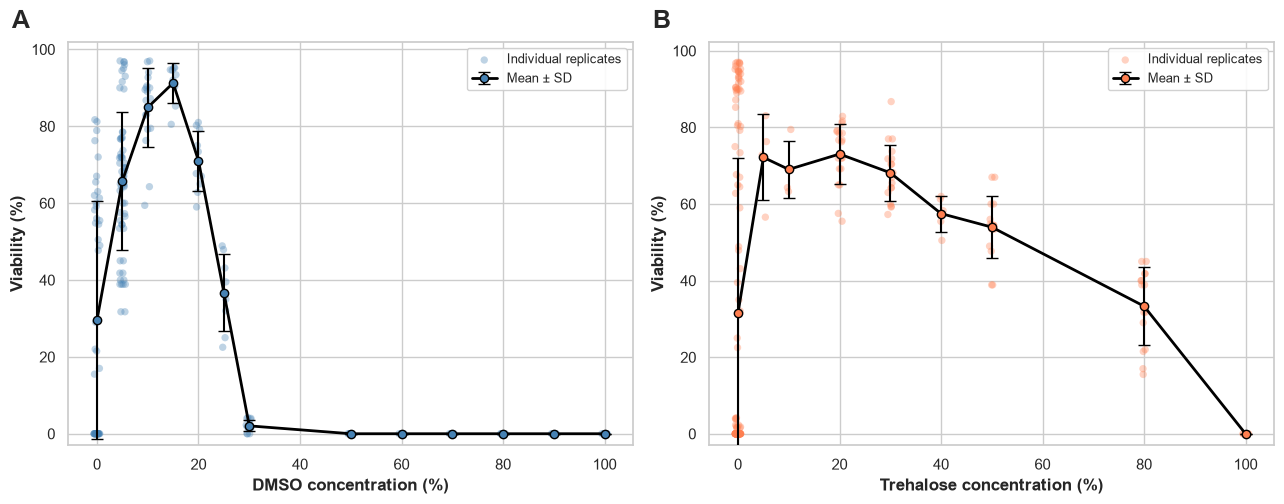


Building viability histogram (separate file)...


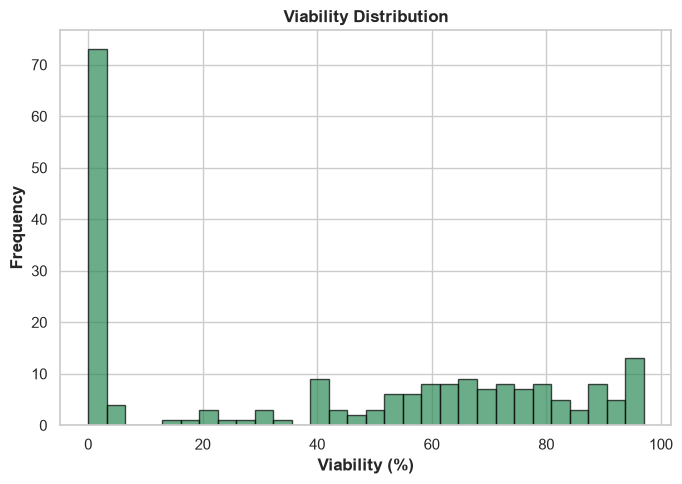

In [5]:
# Panels A (DMSO) and B (Trehalose): mean +/- SD per discrete experimental level,
# over individual (jittered) replicates. No parametric fit -- both cryoprotectants
# were tested at a small number of discrete levels (13 DMSO levels, 9 Trehalose
# levels) with unbalanced replicate counts, and DMSO's effect is a toxicity
# THRESHOLD, not a smooth curve. A polynomial fit here would extrapolate to
# biologically impossible negative viability and misrepresent the threshold.
rng = np.random.default_rng(SEED)


def plot_threshold_panel(ax, x_col, color, label, panel_letter):
    x = df[x_col].values.astype(float)
    y = df['VIABILIDADE'].values.astype(float)

    span = x.max() - x.min()
    jitter = rng.uniform(-1, 1, size=len(x)) * (span * 0.006)
    ax.scatter(x + jitter, y, alpha=0.35, s=28, color=color, edgecolor='none',
               label='Individual replicates', zorder=2)

    levels = np.sort(df[x_col].unique())
    means = np.array([df.loc[df[x_col] == lv, 'VIABILIDADE'].mean() for lv in levels])
    stds = np.array([df.loc[df[x_col] == lv, 'VIABILIDADE'].std() for lv in levels])

    ax.errorbar(levels, means, yerr=stds, fmt='o-', color='black', ecolor='black',
                elinewidth=1.5, capsize=4, markersize=6, markerfacecolor=color,
                markeredgecolor='black', linewidth=2, label='Mean ± SD', zorder=3)

    ax.set_xlabel(f'{label} (%)', fontweight='bold')
    ax.set_ylabel('Viability (%)', fontweight='bold')
    ax.set_ylim(bottom=-3)
    ax.text(-0.10, 1.08, panel_letter, transform=ax.transAxes, fontsize=18,
            fontweight='bold', va='top')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    n_levels = len(levels)
    print(f'  Panel {panel_letter} ({label}): {n_levels} discrete levels, '
          f'n per level = {[int((df[x_col]==lv).sum()) for lv in levels]}')


print('Building Figure 1 (2 panels: A=DMSO, B=Trehalose)...')
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_threshold_panel(axes[0], '% DMSO', 'steelblue', 'DMSO concentration', 'A')
plot_threshold_panel(axes[1], 'TREHALOSE', 'coral', 'Trehalose concentration', 'B')
plt.tight_layout()
plt.savefig('../static/images/eda_concentration_response.png', dpi=300, bbox_inches='tight')
plt.show()

# Viability histogram, kept as a separate figure (previously the 3rd panel here)
print('\nBuilding viability histogram (separate file)...')
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.hist(df['VIABILIDADE'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Viability (%)', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('Viability Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../static/images/eda_viability_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance

In [6]:
# Original features
X_raw = df[['% DMSO', 'TREHALOSE']].values
y_all = df['VIABILIDADE'].values
# Feature importance using Random Forest
rf_temp = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)
rf_temp.fit(X_raw, y_all)
print('Feature Importance:')
for name, imp in zip(['% DMSO', 'TREHALOSE'], rf_temp.feature_importances_):
    print(f'  {name}: {imp:.4f}')

Feature Importance:
  % DMSO: 0.7585
  TREHALOSE: 0.2415


## Data Preparation

In [7]:
# =============================================================
# Triple split: 60% train / 20% validation / 20% test
# =============================================================
# The VALIDATION set is used for Early Stopping and LR Scheduler.
# The TEST set is held out from training and model selection; the same partition
# is used to report every compared model and in the seed-stability check.
# Raw features only: [% DMSO, TREHALOSE]. No feature engineering.
# =============================================================

# Step 1: split into 80% (train+validation) and 20% (test)
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw,
    y_all,
    test_size=0.2,
    random_state=SEED
)

# Step 2: split the 80% into 60% training (fit) and 20% validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    test_size=0.25,
    random_state=SEED
)

# Standardization: fitted ONLY on the fit set, never on validation or test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

N_FIT, N_VAL, N_TEST = len(X_train_scaled), len(X_val_scaled), len(X_test_scaled)
print(f'Train (fit): {N_FIT} samples, {X_train_scaled.shape[1]} features')
print(f'Validation:  {N_VAL} samples')
print(f'Test:        {N_TEST} samples')
print(f'Total:       {N_FIT + N_VAL + N_TEST} samples')

# Guard: the whole analysis assumes the 206-sample dataset. Fail loudly rather
# than silently reporting metrics computed on a different split.
EXPECTED = {'total': 206, 'trainval': 164, 'fit': 123, 'val': 41, 'test': 42}
actual = {'total': len(df), 'trainval': len(X_trainval_raw), 'fit': N_FIT,
          'val': N_VAL, 'test': N_TEST}
assert actual == EXPECTED, f'Unexpected split sizes: {actual} != {EXPECTED}'
print('Split sizes match the expected 206 total / 164 train+val / 123 fit / 41 val / 42 test.')


Train (fit): 123 samples, 2 features
Validation:  41 samples
Test:        42 samples
Total:       206 samples
Split sizes match the expected 206 total / 164 train+val / 123 fit / 41 val / 42 test.


## Neural Network Architecture

* **Input layer**: 2 neurons -- the network uses the two raw concentrations, `% DMSO` and `TREHALOSE`, as inputs; the search below evaluates regularization parameters (BatchNorm, dropout, weight decay)
* **3 hidden layers**: 128 → 64 → 32 neurons
* **Batch Normalization** and **Dropout**: both are now *searched* hyperparameters (see below), not fixed choices
* **ReLU activation** in the hidden layers
* **Output layer**: 1 neuron, linear (predicted cell viability, %); the raw output is not bounded, and the application limits the displayed prediction to the physical range 0-100%

In [8]:
class HepatoCryoNN(nn.Module):
    """Flexible architecture: BatchNorm and Dropout are toggled by config.
    Everything else (128 -> 64 -> 32 -> 1, ReLU on hidden layers, linear output) is fixed."""

    def __init__(self, input_dim=2, use_bn=True, dropout_rate=0.0):
        super().__init__()
        dims = [input_dim, 128, 64, 32]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(32, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_model(X_tr, y_tr, X_vl, y_vl, input_dim, use_bn, dropout, weight_decay,
                 patience, seed, max_epochs=2000, track_history=False, log_every=None):
    """Train one model instance with early stopping on VALIDATION loss.

    Fixed across all configurations: architecture 128->64->32->1, ReLU,
    Adam(lr=1e-3), ReduceLROnPlateau(factor=0.5, patience=30, min_lr=1e-6),
    MSE loss, batch_size=32, CPU, deterministic.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
    X_vl_t = torch.FloatTensor(X_vl).to(DEVICE)
    y_vl_t = torch.FloatTensor(y_vl).unsqueeze(1).to(DEVICE)

    gen = torch.Generator()
    gen.manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=32, shuffle=True, drop_last=True, generator=gen
    )

    model = HepatoCryoNN(input_dim=input_dim, use_bn=use_bn, dropout_rate=dropout).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_epoch = 0
    no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_train_loss = 0.0
        n_batches = 0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            n_batches += 1

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)

        if track_history:
            train_losses.append(epoch_train_loss / max(n_batches, 1))
            val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if log_every and (epoch + 1) % log_every == 0:
            print(f'    epoch {epoch+1:4d} | train_loss={epoch_train_loss/max(n_batches,1):.4f} '
                  f'| val_loss={val_loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.6f}')

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model, best_epoch, best_val_loss, train_losses, val_losses


print('HepatoCryoNN and train_model() defined. Architecture: 2 -> 128 -> 64 -> 32 -> 1 (ReLU on hidden layers, linear output); '
      'batch_norm, dropout, weight_decay, patience are search hyperparameters (see below).')

HepatoCryoNN and train_model() defined. Architecture: 2 -> 128 -> 64 -> 32 -> 1 (ReLU on hidden layers, linear output); batch_norm, dropout, weight_decay, patience are search hyperparameters (see below).


## Hyperparameter Search (selected by VALIDATION loss only)

The regularization configuration is selected on the 206-sample dataset, using the
mean **validation** MSE across seeds. The test set is never used for model
selection, so no configuration choice can leak test information. Whatever wins on
validation loss is what gets trained.

Grid: `batch_norm` in {True, False} x `dropout` in {0.0, 0.2} x `weight_decay` in {0, 1e-4},
with `patience` fixed at 100 = 8 configurations, 2 seeds each (0 and 42) = 16 runs.

Everything else is fixed: architecture 128->64->32->1, ReLU, Adam(lr=1e-3),
`ReduceLROnPlateau(factor=0.5, patience=30, min_lr=1e-6)`, MSE loss, batch_size=32,
max 2000 epochs, early stopping on validation loss.


In [9]:
# ============================================================
# Regularization search, 2 seeds per configuration.
# Selection criterion: mean VALIDATION MSE across seeds (test set untouched).
# ============================================================
grid = list(itertools.product(
    [True, False],       # batch_norm
    [0.0, 0.2],          # dropout
    [0.0, 1e-4],         # weight_decay
))
SEARCH_PATIENCE = 100
search_seeds = [0, 42]

search_rows = []
t_search_start = time.time()

print(f'Running {len(grid)} configurations x {len(search_seeds)} seeds = '
      f'{len(grid) * len(search_seeds)} trainings')
print()

for gi, (use_bn, dropout, wd) in enumerate(grid):
    for seed in search_seeds:
        t0 = time.time()
        _, best_epoch_s, best_val_loss_s, _, _ = train_model(
            X_train_scaled, y_train, X_val_scaled, y_val, input_dim=2,
            use_bn=use_bn, dropout=dropout, weight_decay=wd,
            patience=SEARCH_PATIENCE, seed=seed
        )
        elapsed = time.time() - t0
        search_rows.append({
            'config_id': gi, 'batch_norm': use_bn, 'dropout': dropout,
            'weight_decay': wd, 'patience': SEARCH_PATIENCE, 'seed': seed,
            'best_epoch': best_epoch_s, 'val_loss': best_val_loss_s, 'time_s': elapsed
        })
        print(f'[{gi + 1}/{len(grid)}] bn={use_bn} drop={dropout} wd={wd} '
              f'pat={SEARCH_PATIENCE} seed={seed} -> val_loss={best_val_loss_s:.4f} '
              f'ep={best_epoch_s} ({elapsed:.1f}s) total={time.time() - t_search_start:.0f}s')

search_df = pd.DataFrame(search_rows)

search_summary = search_df.groupby(
    ['config_id', 'batch_norm', 'dropout', 'weight_decay', 'patience']
).agg(
    mean_val_loss=('val_loss', 'mean'),
    std_val_loss=('val_loss', 'std'),
    mean_best_epoch=('best_epoch', 'mean'),
).reset_index().sort_values('mean_val_loss')

print()
print('=== SEARCH SUMMARY (all 8 configurations, sorted by mean validation loss) ===')
print(search_summary.to_string(index=False))

winner = search_summary.iloc[0]
print()
print('WINNER (lowest mean validation loss):', winner.to_dict())
print(f'Total search time: {time.time() - t_search_start:.0f}s')


Running 8 configurations x 2 seeds = 16 trainings



[1/8] bn=True drop=0.0 wd=0.0 pat=100 seed=0 -> val_loss=73.8005 ep=523 (5.4s) total=5s


[1/8] bn=True drop=0.0 wd=0.0 pat=100 seed=42 -> val_loss=56.0825 ep=523 (5.0s) total=10s


[2/8] bn=True drop=0.0 wd=0.0001 pat=100 seed=0 -> val_loss=70.0842 ep=597 (5.7s) total=16s


[2/8] bn=True drop=0.0 wd=0.0001 pat=100 seed=42 -> val_loss=60.7218 ep=423 (4.3s) total=20s


...

[6/8] bn=False drop=0.0 wd=0.0001 pat=100 seed=42 -> val_loss=38.2180 ep=712 (4.0s) total=49s


[7/8] bn=False drop=0.2 wd=0.0 pat=100 seed=0 -> val_loss=88.8599 ep=454 (3.2s) total=53s


[7/8] bn=False drop=0.2 wd=0.0 pat=100 seed=42 -> val_loss=123.0415 ep=568 (3.7s) total=56s


[8/8] bn=False drop=0.2 wd=0.0001 pat=100 seed=0 -> val_loss=146.6621 ep=327 (2.4s) total=59s


[8/8] bn=False drop=0.2 wd=0.0001 pat=100 seed=42 -> val_loss=159.9444 ep=206 (1.7s) total=60s

=== SEARCH SUMMARY (all 8 configurations, sorted by mean validation loss) ===
 config_id  batch_norm  dropout  weight_decay  patience  mean_val_loss  std_val_loss  mean_best_epoch
         0        True      0.0        0.0000       100      64.941467     12.528530            523.0
         1        True      0.0        0.0001       100      65.403027      6.620230            510.0
         5       False      0.0        0.0001       100      75.105967     52.167508            451.0
         4       False      0.0        0.0000       100      83.726553     63.176319            591.0
         2        True      0.2        0.0000       100     101.985180      4.989944            410.0
         3        True      0.2        0.0001       100     104.248947      8.413692            410.0
         6       False      0.2        0.0000       100     105.950710     24.170064            511.0
         7

## Final Model Training (winning configuration, seed=42)

In [10]:
WINNING_CONFIG = dict(
    use_bn=bool(winner['batch_norm']),
    dropout=float(winner['dropout']),
    weight_decay=float(winner['weight_decay']),
    patience=int(winner['patience']),
)
print(f'Training final model with winning configuration: {WINNING_CONFIG}\n')

final_model, best_epoch, best_val_loss, train_losses, val_losses = train_model(
    X_train_scaled, y_train, X_val_scaled, y_val, input_dim=2,
    use_bn=WINNING_CONFIG['use_bn'], dropout=WINNING_CONFIG['dropout'],
    weight_decay=WINNING_CONFIG['weight_decay'], patience=WINNING_CONFIG['patience'],
    seed=42, track_history=True, log_every=100
)

print(f'\nFinal training completed. Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})')

Training final model with winning configuration: {'use_bn': True, 'dropout': 0.0, 'weight_decay': 0.0, 'patience': 100}



    epoch  100 | train_loss=2229.2251 | val_loss=1967.9233 | lr=0.001000


    epoch  200 | train_loss=833.8474 | val_loss=771.2931 | lr=0.001000


    epoch  300 | train_loss=198.1211 | val_loss=122.5790 | lr=0.001000


    epoch  400 | train_loss=124.3993 | val_loss=101.7440 | lr=0.000500


    epoch  500 | train_loss=232.3560 | val_loss=71.5282 | lr=0.000125


    epoch  600 | train_loss=109.3201 | val_loss=66.2482 | lr=0.000031

Final training completed. Best epoch: 523 (Val Loss: 56.0825)


In [11]:
print('Best model (from validation-based early stopping) is already loaded into `final_model`.')
print(f'Winning configuration: {WINNING_CONFIG}')
print(f'Best epoch: {best_epoch}')

Best model (from validation-based early stopping) is already loaded into `final_model`.
Winning configuration: {'use_bn': True, 'dropout': 0.0, 'weight_decay': 0.0, 'patience': 100}
Best epoch: 523


## Evaluation: Fit / Validation / Test Sets

In [12]:
# Final predictions on the held-out test set (not used for training or model selection)
final_model.eval()
with torch.no_grad():
    y_pred_train = final_model(torch.FloatTensor(X_train_scaled)).numpy().flatten()
    y_pred_val   = final_model(torch.FloatTensor(X_val_scaled)).numpy().flatten()
    y_pred_test  = final_model(torch.FloatTensor(X_test_scaled)).numpy().flatten()

r2_train = r2_score(y_train, y_pred_train)
r2_val   = r2_score(y_val,   y_pred_val)
r2_test  = r2_score(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_val,   y_pred_val))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

residuals_test = y_test - y_pred_test
resid_mean = residuals_test.mean()
resid_std  = residuals_test.std()

print('PERFORMANCE METRICS - NEURAL NETWORK (PyTorch, raw features)')
print()
print(f'Fit ({N_FIT})         -> R2 = {r2_train:.4f} | RMSE = {rmse_train:.4f} pp')
print(f'Validation ({N_VAL})  -> R2 = {r2_val:.4f} | RMSE = {rmse_val:.4f} pp')
print(f'Test ({N_TEST})        -> R2 = {r2_test:.4f} | RMSE = {rmse_test:.4f} pp')
print()
print(f'Best epoch (early stopping): {best_epoch}')
print(f'Test residuals   -> mean = {resid_mean:.4f} | std = {resid_std:.4f}')

if r2_test < 0.85:
    print()
    print('*** WARNING: test R2 below the 0.85 sanity threshold. Investigate before concluding. ***')
else:
    print()
    print(f'Test R2 = {r2_test:.4f} is above the 0.85 sanity threshold.')


PERFORMANCE METRICS - NEURAL NETWORK (PyTorch, raw features)

Fit (123)         -> R2 = 0.9707 | RMSE = 6.1650 pp
Validation (41)  -> R2 = 0.9538 | RMSE = 7.4888 pp
Test (42)        -> R2 = 0.9818 | RMSE = 4.9177 pp

Best epoch (early stopping): 523
Test residuals   -> mean = -0.6783 | std = 4.8707

Test R2 = 0.9818 is above the 0.85 sanity threshold.


## View

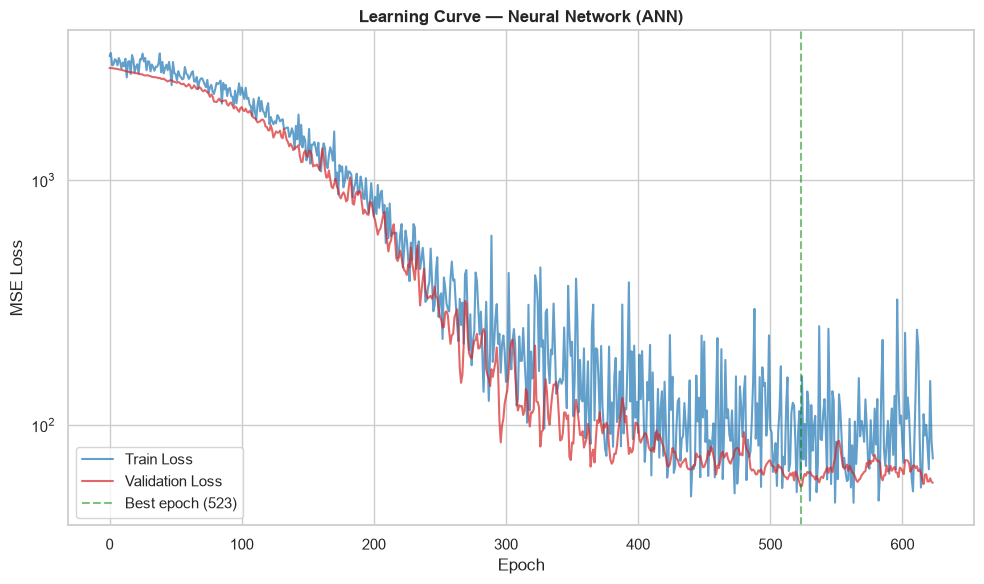

In [13]:
# Loss Curve (Training vs Validation)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train Loss', color='#1f77b4', alpha=0.7)
ax.plot(val_losses, label='Validation Loss', color='#d62728', alpha=0.7)
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Learning Curve — Neural Network (ANN)', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../static/images/nn_loss_curve.png', dpi=300)
plt.show()

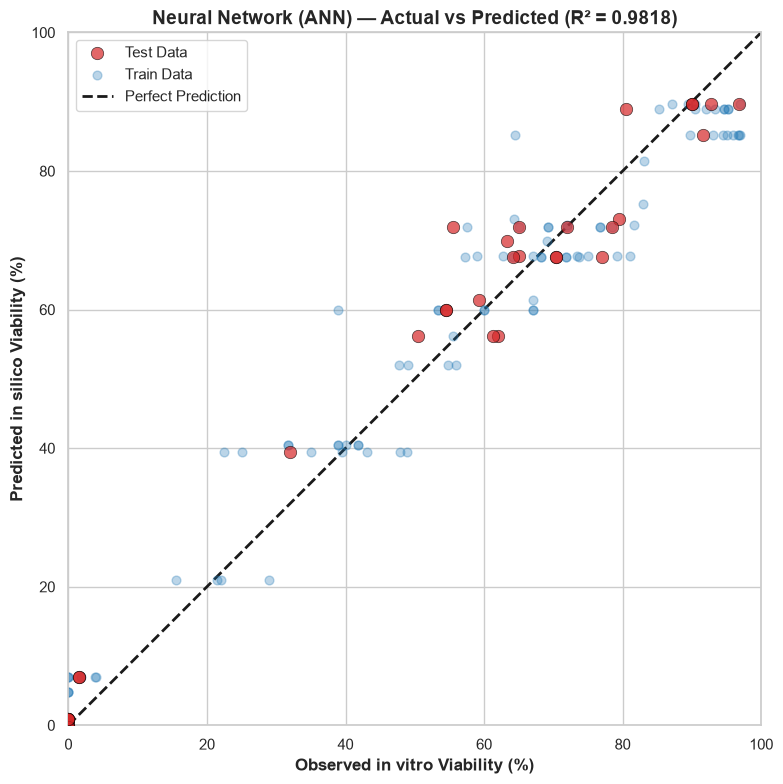

In [14]:
# Plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_test, alpha=0.7, color='#d62728', s=80, 
           edgecolors='black', linewidths=0.5, label='Test Data', zorder=3)
ax.scatter(y_train, y_pred_train, alpha=0.3, color='#1f77b4', s=40, 
           label='Train Data', zorder=2)

lims = [min(y_all.min(), 0), max(y_all.max(), 100)]
ax.plot(lims, lims, 'k--', lw=2, label='Perfect Prediction', zorder=1)

ax.set_xlabel('Observed in vitro Viability (%)', fontweight='bold')
ax.set_ylabel('Predicted in silico Viability (%)', fontweight='bold')
ax.set_title(f'Neural Network (ANN) — Actual vs Predicted (R² = {r2_test:.4f})', fontweight='bold', fontsize=14)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../static/images/nn_actual_vs_predicted.png', dpi=300)
plt.show()

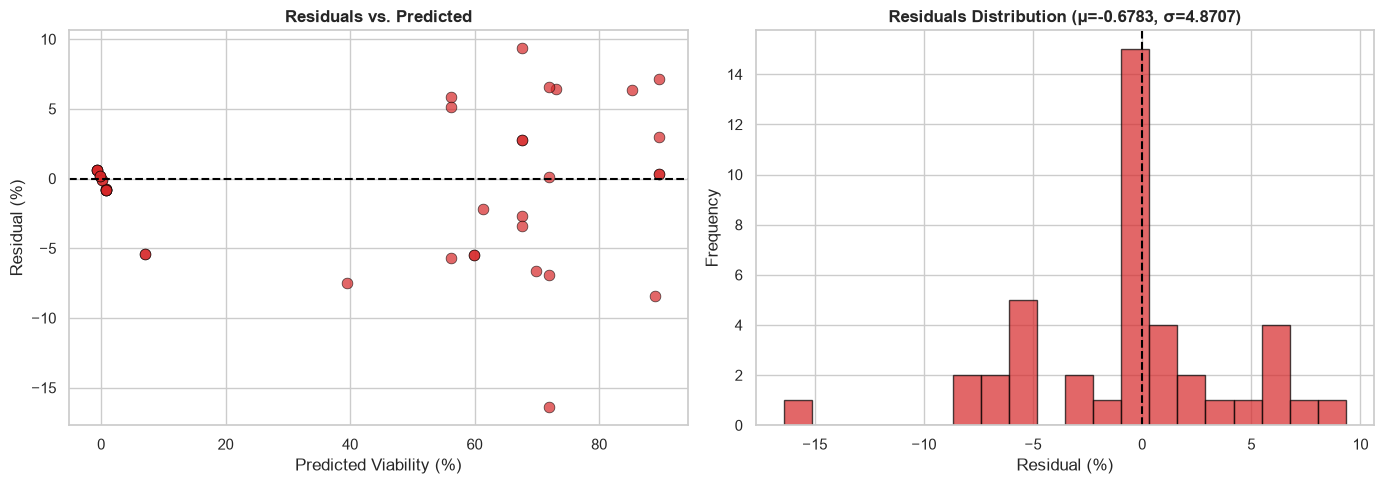

In [15]:
# Residuals Plot
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.7, color='#d62728', s=60, edgecolors='black', linewidths=0.5)
axes[0].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted Viability (%)')
axes[0].set_ylabel('Residual (%)')
axes[0].set_title('Residuals vs. Predicted', fontweight='bold')

# Distribution of Residuals
axes[1].hist(residuals, bins=20, color='#d62728', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution (μ={residuals.mean():.4f}, σ={residuals.std():.4f})', fontweight='bold')

plt.tight_layout()
plt.savefig('../static/images/nn_residuals.png', dpi=300)
plt.show()

## K-Fold Cross-Validation (K=5)

Runs over the 164 train+validation samples only (the 42-sample test set stays
untouched) using the winning configuration from the search above. The
`StandardScaler` is refit inside each fold to avoid leakage.


In [16]:
def train_and_evaluate_fold(X_train_f, y_train_f, X_val_f, y_val_f, input_dim, config, seed=SEED):
    """Train one fold of the neural network (winning configuration) and return its validation metrics."""
    fold_model, fold_best_epoch, fold_best_val_loss, _, _ = train_model(
        X_train_f, y_train_f, X_val_f, y_val_f, input_dim=input_dim,
        use_bn=config['use_bn'], dropout=config['dropout'],
        weight_decay=config['weight_decay'], patience=config['patience'], seed=seed
    )
    fold_model.eval()
    with torch.no_grad():
        y_pred_val = fold_model(torch.FloatTensor(X_val_f)).numpy().flatten()
    r2 = r2_score(y_val_f, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val_f, y_pred_val))
    return r2, rmse, fold_best_epoch


# ============================================================
# 5-fold CV over the 164 train+val samples (test set stays untouched).
# StandardScaler is refit INSIDE each fold to avoid leakage.
# ============================================================
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

fold_r2 = []
fold_rmse = []

print('--- K-FOLD CROSS-VALIDATION (K=5, winning configuration) ---\n')

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval_raw)):

    X_tr_raw_f = X_trainval_raw[train_idx]
    X_vl_raw_f = X_trainval_raw[val_idx]

    y_tr_f = y_trainval[train_idx]
    y_vl_f = y_trainval[val_idx]

    # Standardization refit on this fold's training data only
    sc_f = StandardScaler()
    X_tr_sc_f = sc_f.fit_transform(X_tr_raw_f)
    X_vl_sc_f = sc_f.transform(X_vl_raw_f)

    r2, rmse, ep = train_and_evaluate_fold(
        X_tr_sc_f, y_tr_f, X_vl_sc_f, y_vl_f, input_dim=2, config=WINNING_CONFIG
    )

    fold_r2.append(r2)
    fold_rmse.append(rmse)

    print(f'  Fold {fold + 1}: R² = {r2:.4f} | RMSE = {rmse:.4f} | best_epoch = {ep}')

print(f'\n  MEAN: R² = {np.mean(fold_r2):.4f} (+/- {np.std(fold_r2):.4f})')
print(f'  MEAN: RMSE = {np.mean(fold_rmse):.4f} (+/- {np.std(fold_rmse):.4f})')

--- K-FOLD CROSS-VALIDATION (K=5, winning configuration) ---



  Fold 1: R² = 0.9488 | RMSE = 7.9389 | best_epoch = 309


  Fold 2: R² = 0.9595 | RMSE = 6.9595 | best_epoch = 293


  Fold 3: R² = 0.9615 | RMSE = 6.8350 | best_epoch = 360


  Fold 4: R² = 0.9731 | RMSE = 6.1535 | best_epoch = 317


  Fold 5: R² = 0.9785 | RMSE = 5.1378 | best_epoch = 418

  MEAN: R² = 0.9643 (+/- 0.0105)
  MEAN: RMSE = 6.6049 (+/- 0.9289)


## Seed-Stability Check (control only — not a headline result)

Retrains the final configuration with 5 different seeds (0, 1, 2, 42, 123) and
reports the mean ± std of the R² on the same test partition. This is a robustness control, not part
of the paper's primary result.

In [17]:
stability_seeds = [0, 1, 2, 42, 123]
stability_r2 = []

print('--- SEED-STABILITY CHECK ---\n')

for s in stability_seeds:
    m_s, ep_s, vl_s, _, _ = train_model(
        X_train_scaled, y_train, X_val_scaled, y_val, input_dim=2,
        use_bn=WINNING_CONFIG['use_bn'], dropout=WINNING_CONFIG['dropout'],
        weight_decay=WINNING_CONFIG['weight_decay'], patience=WINNING_CONFIG['patience'],
        seed=s
    )
    m_s.eval()
    with torch.no_grad():
        y_pred_s = m_s(torch.FloatTensor(X_test_scaled)).numpy().flatten()
    r2_s = r2_score(y_test, y_pred_s)
    stability_r2.append(r2_s)
    print(f'  seed={s:4d} -> test R² = {r2_s:.4f} (best_epoch={ep_s})')

stability_mean = np.mean(stability_r2)
stability_std = np.std(stability_r2)

print(f'\nTest R² across seeds: {stability_mean:.4f} +/- {stability_std:.4f}')

if stability_std > 0.05:
    print(f'*** WARNING: seed std ({stability_std:.4f}) > 0.05 -- result is SENSITIVE TO SEED. ***')
else:
    print(f'Seed std ({stability_std:.4f}) <= 0.05 -- result is reasonably stable across seeds.')

--- SEED-STABILITY CHECK ---



  seed=   0 -> test R² = 0.9825 (best_epoch=523)


  seed=   1 -> test R² = 0.9741 (best_epoch=443)


  seed=   2 -> test R² = 0.9757 (best_epoch=457)


  seed=  42 -> test R² = 0.9818 (best_epoch=523)


  seed= 123 -> test R² = 0.9772 (best_epoch=374)

Test R² across seeds: 0.9782 +/- 0.0033
Seed std (0.0033) <= 0.05 -- result is reasonably stable across seeds.


## Final Comparison: Random Forest vs. Neural Network

In [18]:
# Random Forest trained under the same conditions
# (using only raw features, with 60% training data)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)

rf_model.fit(X_train_raw, y_train)

y_pred_rf = rf_model.predict(X_test_raw)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'Random Forest -> R² = {r2_rf:.4f} | RMSE = {rmse_rf:.2f} pp')
print(f'Neural Network -> R² = {r2_test:.4f} | RMSE = {rmse_test:.2f} pp')

Random Forest -> R² = 0.9818 | RMSE = 4.91 pp
Neural Network -> R² = 0.9818 | RMSE = 4.92 pp


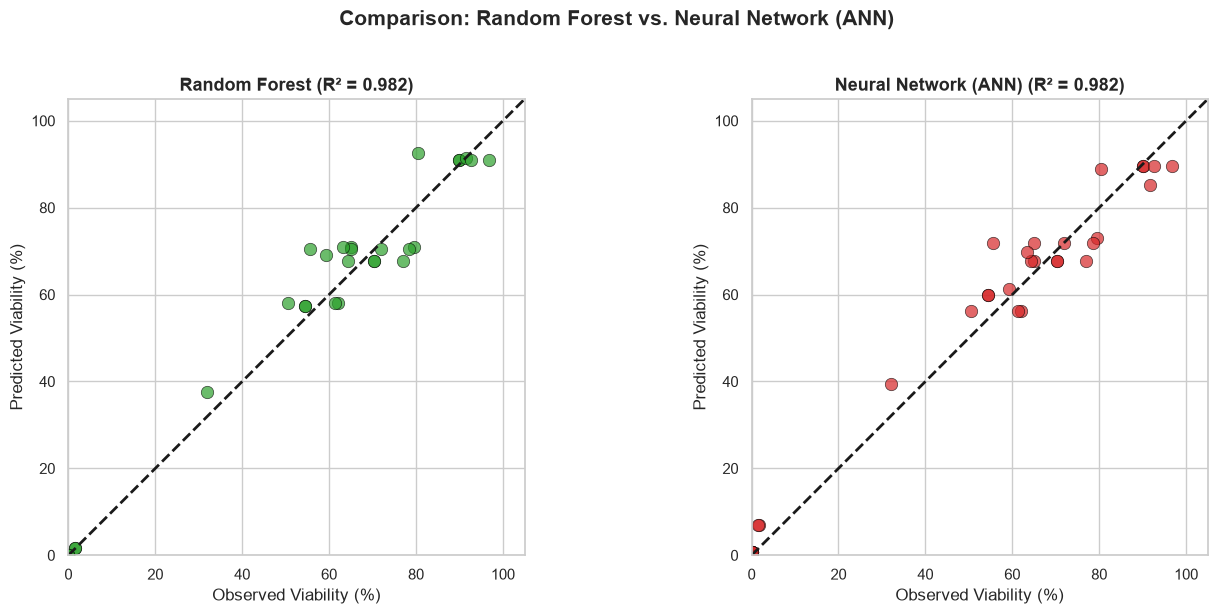

In [19]:
# Comparative plot: side-by-side scatter plots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lims = [0, 105]

# Random Forest
axes[0].scatter(
    y_test,
    y_pred_rf,
    alpha=0.7,
    color='#2ca02c',
    s=80,
    edgecolors='black',
    linewidths=0.5
)
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlabel('Observed Viability (%)')
axes[0].set_ylabel('Predicted Viability (%)')
axes[0].set_title(
    f'Random Forest (R² = {r2_rf:.3f})',
    fontweight='bold',
    fontsize=13
)

axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect('equal')

# Neural Network
axes[1].scatter(
    y_test,
    y_pred_test,
    alpha=0.7,
    color="#d62728",
    s=80,
    edgecolors='black',
    linewidths=0.5
)

axes[1].plot(lims, lims, 'k--', lw=2)
axes[1].set_xlabel('Observed Viability (%)')
axes[1].set_ylabel('Predicted Viability (%)')
axes[1].set_title(
    f'Neural Network (ANN) (R² = {r2_test:.3f})',
    fontweight='bold',
    fontsize=13
)

axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_aspect('equal')

plt.suptitle(
    'Comparison: Random Forest vs. Neural Network (ANN)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('../static/images/rf_vs_nn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Export

Two artifacts are produced:
1. `../models/nn_model.pth` -- the trained PyTorch weights (kept for reproducibility/provenance).
2. `../models/nn_weights.npz` -- everything needed for **NumPy-only** inference in production: the
   `StandardScaler` parameters and the network's `Linear` weights. The selected configuration
   uses BatchNorm; at export, each Linear layer followed by BatchNorm is fused into a single
   affine transformation, so NumPy inference is a plain sequence of affine layers with ReLU.

`../src/nn_inference.py` implements `predict(dmso, trehalose)` using only NumPy and is validated
below against the PyTorch model on a dense concentration grid.

In [20]:
def fold_bn_into_linear(linear, bn):
    """Fuse Linear + eval-mode BatchNorm1d into a single affine Linear transform."""
    W = linear.weight.detach().numpy()
    b = linear.bias.detach().numpy()
    gamma = bn.weight.detach().numpy()
    beta = bn.bias.detach().numpy()
    running_mean = bn.running_mean.detach().numpy()
    running_var = bn.running_var.detach().numpy()
    eps = bn.eps
    scale = gamma / np.sqrt(running_var + eps)
    return W * scale[:, None], scale * (b - running_mean) + beta


def export_layers(model):
    """Walk the Sequential, folding any Linear+BatchNorm pair; Dropout/ReLU are
    identity/structural in eval mode and are not stored."""
    modules = list(model.network)
    layers = []
    i, n = 0, len(modules)
    while i < n:
        mod = modules[i]
        if isinstance(mod, nn.Linear):
            if i + 1 < n and isinstance(modules[i + 1], nn.BatchNorm1d):
                W, b = fold_bn_into_linear(mod, modules[i + 1])
                i += 2
            else:
                W = mod.weight.detach().numpy()
                b = mod.bias.detach().numpy()
                i += 1
            layers.append((W.astype(np.float64), b.astype(np.float64)))
        else:
            i += 1
    return layers


exported_layers = export_layers(final_model)
print(f'Exported {len(exported_layers)} Linear(+ReLU) layers:')
for i, (W, b) in enumerate(exported_layers):
    print(f'  Layer {i}: W{W.shape} b{b.shape}')

npz_kwargs = {
    'mean': scaler.mean_.astype(np.float64),
    'scale': scaler.scale_.astype(np.float64),
    'n_layers': len(exported_layers),
}
for i, (W, b) in enumerate(exported_layers):
    npz_kwargs[f'W{i}'] = W
    npz_kwargs[f'b{i}'] = b

torch.save(final_model.state_dict(), '../models/nn_model.pth')
np.savez('../models/nn_weights.npz', **npz_kwargs)

print('\nFiles saved:')
print('  - ../models/nn_model.pth   (PyTorch weights, reproducibility/provenance)')
print('  - ../models/nn_weights.npz (StandardScaler + Linear weights, NumPy-only inference)')

Exported 4 Linear(+ReLU) layers:
  Layer 0: W(128, 2) b(128,)
  Layer 1: W(64, 128) b(64,)
  Layer 2: W(32, 64) b(32,)
  Layer 3: W(1, 32) b(1,)

Files saved:
  - ../models/nn_model.pth   (PyTorch weights, reproducibility/provenance)
  - ../models/nn_weights.npz (StandardScaler + Linear weights, NumPy-only inference)


## Acceptance Test — PyTorch vs. NumPy Inference

`src/nn_inference.py` must reproduce the PyTorch model's predictions using only NumPy.
This validates the exported artifact on a dense grid (DMSO 0-100, Trehalose 0-100,
step 1%, respecting DMSO + Trehalose ≤ 100). Required: max absolute difference < 1e-4.

In [21]:
import sys
sys.path.insert(0, '../src')
import importlib
import nn_inference
importlib.reload(nn_inference)

dmso_vals = np.arange(0, 101, 1)
treh_vals = np.arange(0, 101, 1)
export_grid = [(d, t) for d, t in itertools.product(dmso_vals, treh_vals) if d + t <= 100]
grid_arr = np.array(export_grid, dtype=np.float64)
print(f'Grid size: {len(export_grid)} points (DMSO 0-100, Trehalose 0-100, step 1, sum <= 100)')

grid_scaled = scaler.transform(grid_arr)
final_model.eval()
with torch.no_grad():
    y_torch = final_model(torch.FloatTensor(grid_scaled)).numpy().flatten()

y_numpy = np.array([nn_inference.predict(d, t) for d, t in export_grid])

max_abs_diff = float(np.max(np.abs(y_torch - y_numpy)))
print(f'Max abs diff (PyTorch vs NumPy) over {len(export_grid)} grid points: {max_abs_diff:.3e}')

if max_abs_diff < 1e-4:
    print('PASS: max abs diff < 1e-4')
else:
    raise AssertionError('NumPy export does not match PyTorch within 1e-4 -- fix before proceeding!')

# Example used in the figure legend of the paper: 10% DMSO, 0% trehalose.
example_dmso, example_treh = 10.0, 0.0
example_torch = float(final_model(
    torch.FloatTensor(scaler.transform([[example_dmso, example_treh]]))
).item())
example_numpy = nn_inference.predict(example_dmso, example_treh)
print()
print(f'Example {example_dmso:.0f}% DMSO / {example_treh:.0f}% Trehalose -> '
      f'PyTorch = {example_torch:.4f} | NumPy = {example_numpy:.4f}')


Grid size: 5151 points (DMSO 0-100, Trehalose 0-100, step 1, sum <= 100)
Max abs diff (PyTorch vs NumPy) over 5151 grid points: 7.714e-05
PASS: max abs diff < 1e-4

Example 10% DMSO / 0% Trehalose -> PyTorch = 89.6854 | NumPy = 89.6854


## Updating `metrics.json`

`metrics.json` was created by `01_random_forest.ipynb`. This notebook loads it, adds the
`neural_network` section (search result, final metrics, cross-validation, seed stability
and the NumPy export check) and writes it back.


In [22]:
import json

METRICS_PATH = '../metrics.json'
with open(METRICS_PATH, encoding='utf-8') as f:
    metrics = json.load(f)

search_table = [
    {
        'batch_norm': bool(r['batch_norm']),
        'dropout': float(r['dropout']),
        'weight_decay': float(r['weight_decay']),
        'patience': int(r['patience']),
        'mean_val_loss': round(float(r['mean_val_loss']), 4),
        'std_val_loss': round(float(r['std_val_loss']), 4),
        'mean_best_epoch': round(float(r['mean_best_epoch']), 1),
    }
    for _, r in search_summary.iterrows()
]

metrics['neural_network'] = {
    'features': ['% DMSO', 'TREHALOSE'],
    'architecture': '2 -> 128 -> 64 -> 32 -> 1 (ReLU on hidden layers, linear output)',
    'winning_config': {
        'use_bn': bool(WINNING_CONFIG['use_bn']),
        'dropout': float(WINNING_CONFIG['dropout']),
        'weight_decay': float(WINNING_CONFIG['weight_decay']),
        'patience': int(WINNING_CONFIG['patience']),
    },
    'search_winner_mean_val_loss': round(float(winner['mean_val_loss']), 4),
    'hyperparameter_search': {
        'note': ('Selected by mean validation MSE across seeds [0, 42]; the test set is '
                 'never used for model selection. Grid: batch_norm x dropout x weight_decay, '
                 'patience fixed at 100.'),
        'seeds': search_seeds,
        'n_configs': int(len(search_summary)),
        'n_runs': len(search_rows),
        'table': search_table,
    },
    'r2_fit': round(float(r2_train), 4),
    'rmse_fit': round(float(rmse_train), 4),
    'r2_val': round(float(r2_val), 4),
    'rmse_val': round(float(rmse_val), 4),
    'r2_test': round(float(r2_test), 4),
    'rmse_test': round(float(rmse_test), 4),
    'best_epoch': int(best_epoch),
    'residuals_test_mean': round(float(resid_mean), 4),
    'residuals_test_std': round(float(resid_std), 4),
    'cv_r2_mean': round(float(np.mean(fold_r2)), 4),
    'cv_r2_std': round(float(np.std(fold_r2)), 4),
    'cv_rmse_mean': round(float(np.mean(fold_rmse)), 4),
    'cv_rmse_std': round(float(np.std(fold_rmse)), 4),
    'cv_per_fold_r2': [round(float(v), 4) for v in fold_r2],
    'cv_per_fold_rmse': [round(float(v), 4) for v in fold_rmse],
    'seed_stability_check': {
        'seeds': stability_seeds,
        'r2_per_seed': [round(float(v), 4) for v in stability_r2],
        'r2_mean': round(float(stability_mean), 4),
        'r2_std': round(float(stability_std), 4),
        'sensitive_to_seed': bool(stability_std > 0.05),
        'note': 'Control check only, not a headline result.',
    },
    'numpy_export_validation': {
        'grid_size': int(len(export_grid)),
        'max_abs_diff': max_abs_diff,
        'passed': bool(max_abs_diff < 1e-4),
    },
}

metrics['example_prediction_10dmso_0trehalose'] = {
    'neural_network_pytorch': round(example_torch, 4),
    'neural_network_numpy': round(example_numpy, 4),
}

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'Updated {METRICS_PATH} -> sections: {list(metrics)}')
print(f"  winning config: {metrics['neural_network']['winning_config']}")
print(f"  test R2: {metrics['neural_network']['r2_test']} | "
      f"CV R2: {metrics['neural_network']['cv_r2_mean']}")


Updated ../metrics.json -> sections: ['generated_at', 'dataset', 'random_forest', 'random_forest_numpy_export_validation', 'neural_network', 'example_prediction_10dmso_0trehalose', 'alternatives', 'baselines']
  winning config: {'use_bn': True, 'dropout': 0.0, 'weight_decay': 0.0, 'patience': 100}
  test R2: 0.9818 | CV R2: 0.9643
